In [27]:
import math
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

In [3]:
matrix = np.array([
    [0, 1, 1, 0, 0, 0],
    [0, 0, 1, 0, 1, 1],
    [1, 0, 0, 1, 0, 1],
    [0, 0, 1, 0, 1, 0],
    [0, 1, 0, 1, 0, 0],
    [0, 1, 3, 0, 0, 0],
])

In [4]:
G = nx.from_numpy_array(matrix)

In [5]:
pos = nx.spring_layout(G)
_ = nx.spring_layout(G, seed=123, store_pos_as="pos")

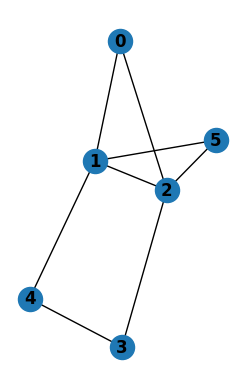

In [6]:
subax1 = plt.subplot(121)
nx.draw(G, with_labels=True, font_weight='bold', pos=pos)
plt.show()

In [7]:
G.nodes(data=True)

NodeDataView({0: {'pos': array([-0.9965034 , -0.29936475])}, 1: {'pos': array([-0.16841707, -0.31487662])}, 2: {'pos': array([-0.1354575,  0.3636466])}, 3: {'pos': array([1.        , 0.22504569])}, 4: {'pos': array([ 0.88180525, -0.6663233 ])}, 5: {'pos': array([-0.58142728,  0.69187239])}})

In [8]:
G.nodes, G.edges

EdgeView([(0, 1), (0, 2), (1, 2), (1, 4), (1, 5), (2, 3), (2, 5), (3, 4)])

In [9]:
weights = np.array([
    [1],
    [0],
    [0],
    [0],
    [0],
    [0]
])
weights

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [ ]:
weights_map = {i: weights[i] for i in range(len(weights))}

In [11]:
nx.set_node_attributes(G, weights_map, "weights")

In [12]:
G.nodes[0]["weights"]

array([1])

In [13]:
G.nodes(data=True)

NodeDataView({0: {'pos': array([-0.9965034 , -0.29936475]), 'weights': array([1])}, 1: {'pos': array([-0.16841707, -0.31487662]), 'weights': array([0])}, 2: {'pos': array([-0.1354575,  0.3636466]), 'weights': array([0])}, 3: {'pos': array([1.        , 0.22504569]), 'weights': array([0])}, 4: {'pos': array([ 0.88180525, -0.6663233 ]), 'weights': array([0])}, 5: {'pos': array([-0.58142728,  0.69187239]), 'weights': array([0])}})

In [14]:
adjacency_mat = nx.to_numpy_array(G)
adjacency_mat

array([[0., 1., 1., 0., 0., 0.],
       [1., 0., 1., 0., 1., 1.],
       [1., 1., 0., 1., 0., 3.],
       [0., 0., 1., 0., 1., 0.],
       [0., 1., 0., 1., 0., 0.],
       [0., 1., 3., 0., 0., 0.]])

In [15]:
features = np.array([G.nodes[i]['weights'] for i in G.nodes])
features

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [16]:
num_step = 10
feature_hist = [features.copy()]
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]])]

In [17]:
for _ in range(num_step):
    features = adjacency_mat @ features
    feature_hist.append(features)

## Adjacency Diffusion

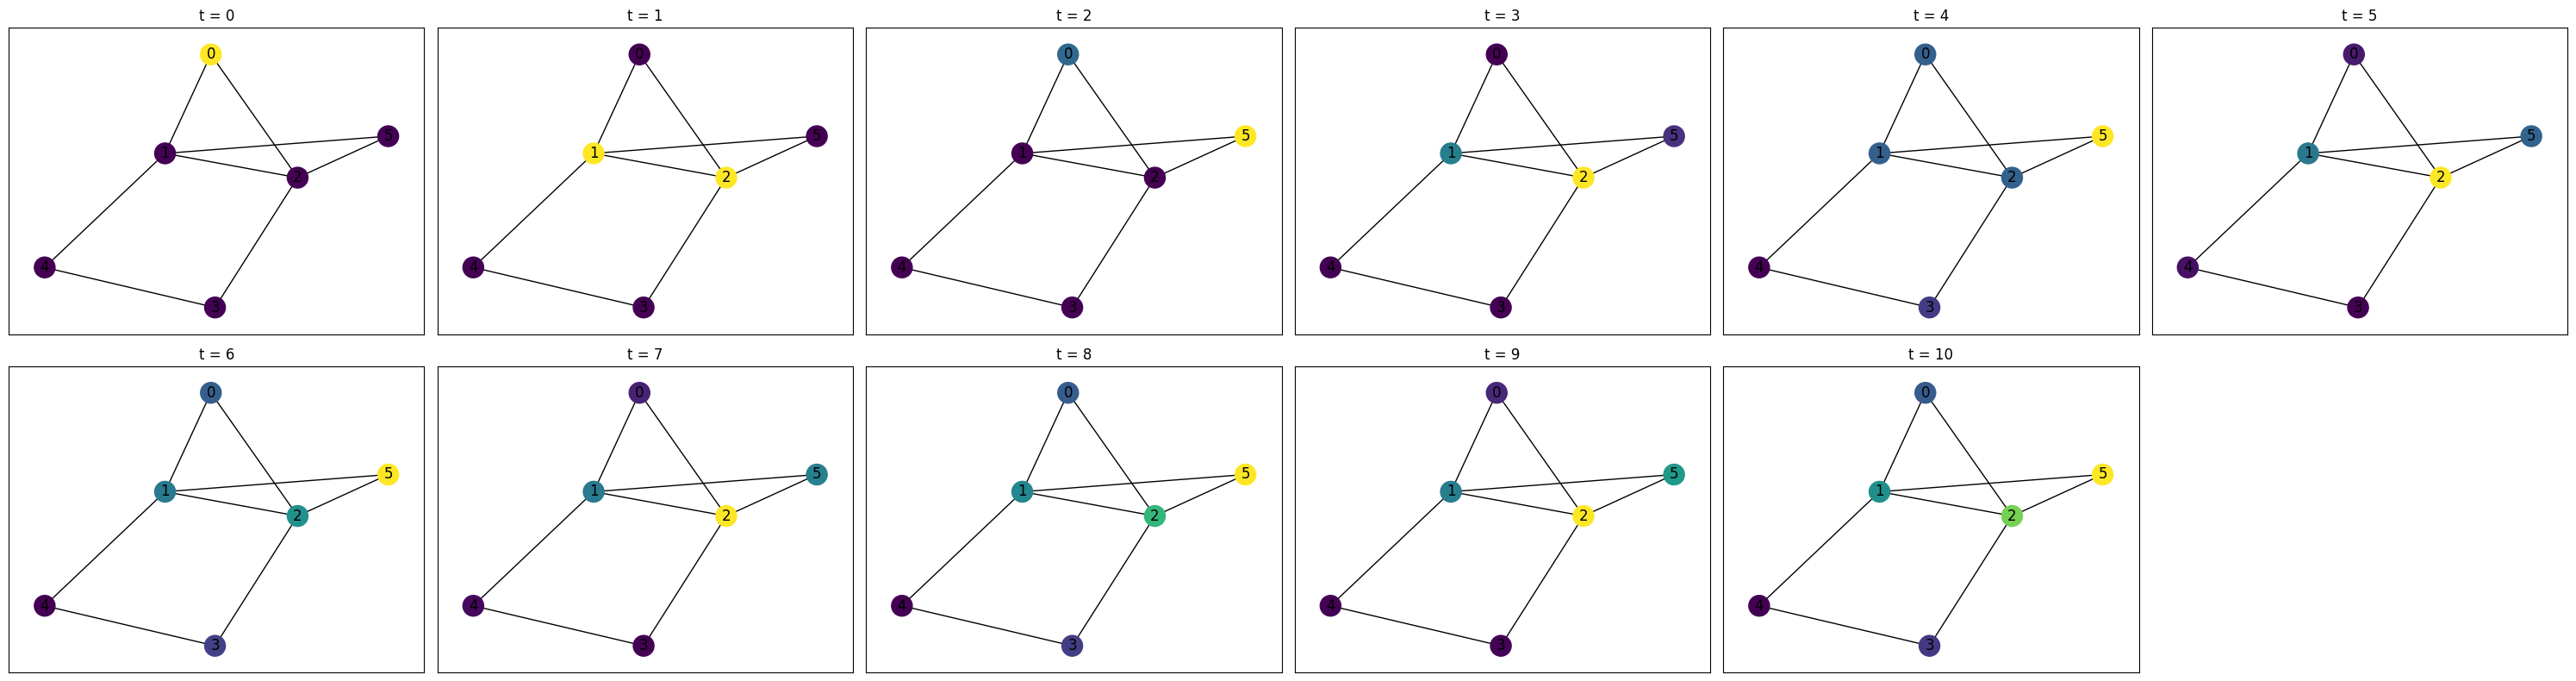

In [21]:
n = len(feature_hist)
rows = 2
cols = math.ceil(n / rows)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

# Flatten axes array (important!)
axes = axes.flatten()

for t, (feat, ax) in enumerate(zip(feature_hist, axes)):
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feat,
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")

# Hide unused subplots (if any)
for ax in axes[len(feature_hist):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

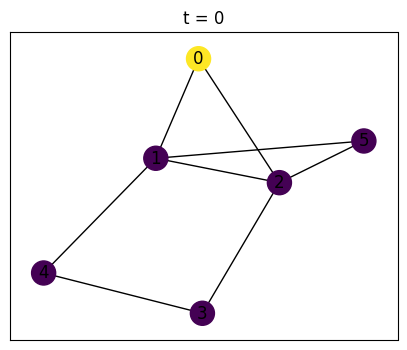

In [28]:
fig, ax = plt.subplots(figsize=(5,4))

def update(t):
    ax.clear()
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feature_hist[t],
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")

ani = FuncAnimation(fig, update, frames=len(feature_hist), interval=1000)

HTML(ani.to_jshtml())

## Asymmetric Normalized Adjacency Matrix  - Random Walk

In [36]:
degrees = np.sum(adjacency_mat, axis=1)
degrees[degrees == 0] = 1
degree_mat = np.diag(degrees)
degree_mat

array([[2., 0., 0., 0., 0., 0.],
       [0., 4., 0., 0., 0., 0.],
       [0., 0., 6., 0., 0., 0.],
       [0., 0., 0., 2., 0., 0.],
       [0., 0., 0., 0., 2., 0.],
       [0., 0., 0., 0., 0., 4.]])

In [38]:
degree_inv = np.linalg.inv(degree_mat)
degree_inv

array([[0.5       , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.25      , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.16666667, 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.5       , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.5       ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.25      ]])

In [40]:
A_rw = degree_inv @ adjacency_mat
A_rw

array([[0.        , 0.5       , 0.5       , 0.        , 0.        ,
        0.        ],
       [0.25      , 0.        , 0.25      , 0.        , 0.25      ,
        0.25      ],
       [0.16666667, 0.16666667, 0.        , 0.16666667, 0.        ,
        0.5       ],
       [0.        , 0.        , 0.5       , 0.        , 0.5       ,
        0.        ],
       [0.        , 0.5       , 0.        , 0.5       , 0.        ,
        0.        ],
       [0.        , 0.25      , 0.75      , 0.        , 0.        ,
        0.        ]])

In [50]:
features = np.array([G.nodes[i]['weights'] for i in G.nodes])
features

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [51]:
num_step = 10
feature_hist = [features.copy()]
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]])]

In [52]:
for _ in range(num_step):
    features = A_rw @ features
    feature_hist.append(features)


In [53]:
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]]),
 array([[0.        ],
        [0.25      ],
        [0.16666667],
        [0.        ],
        [0.        ],
        [0.        ]]),
 array([[0.20833333],
        [0.04166667],
        [0.04166667],
        [0.08333333],
        [0.125     ],
        [0.1875    ]]),
 array([[0.04166667],
        [0.140625  ],
        [0.14930556],
        [0.08333333],
        [0.0625    ],
        [0.04166667]]),
 array([[0.14496528],
        [0.07378472],
        [0.06510417],
        [0.10590278],
        [0.11197917],
        [0.14713542]]),
 array([[0.06944444],
        [0.11729601],
        [0.1276765 ],
        [0.08854167],
        [0.08984375],
        [0.06727431]]),
 array([[0.12248626],
        [0.08855975],
        [0.07951751],
        [0.10876013],
        [0.10291884],
        [0.12508138]]),
 array([[0.08403863],
        [0.10750099],
        [0.11584171],
        [0.09121817],
        [0.09865994],
      

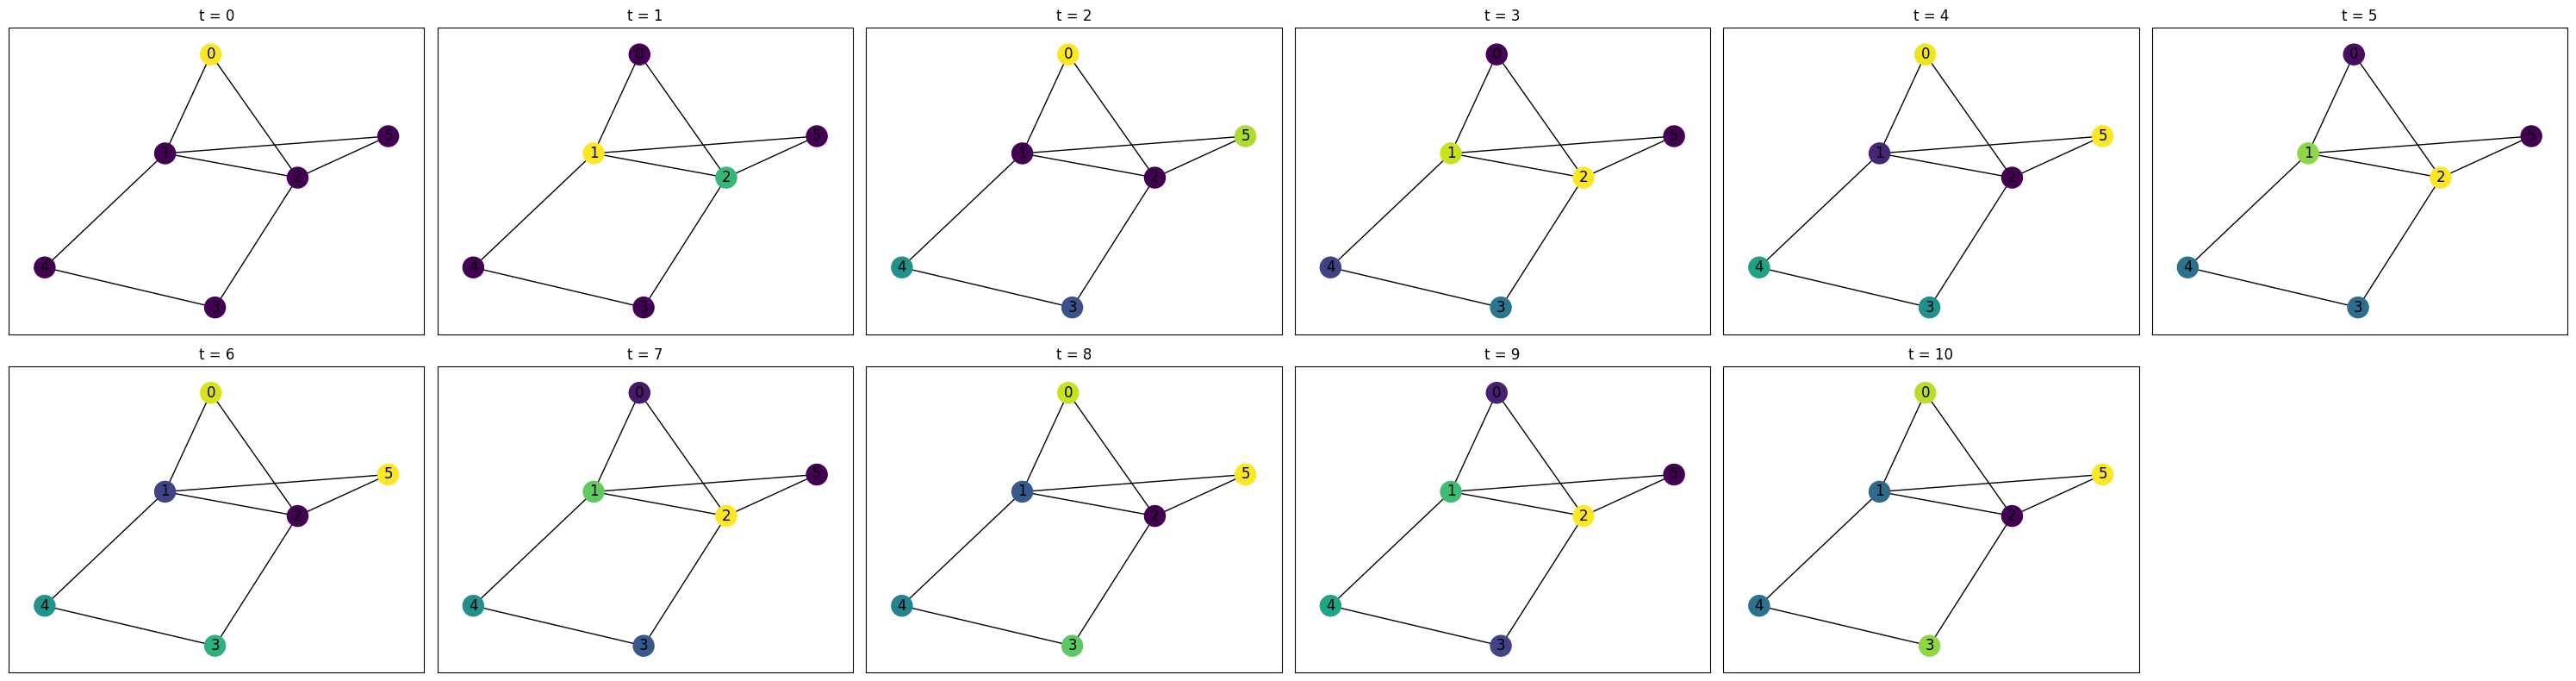

In [ ]:
n = len(feature_hist)
rows = 2
cols = math.ceil(n / rows)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for t, (feat, ax) in enumerate(zip(feature_hist, axes)):
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feat,
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")
    
for ax in axes[len(feature_hist):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

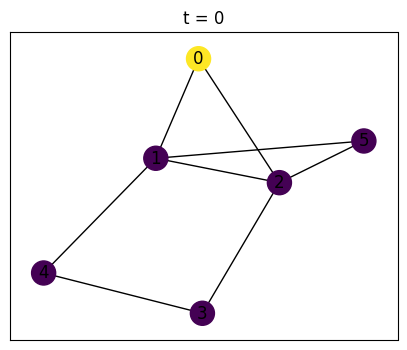

In [56]:
fig, ax = plt.subplots(figsize=(5,4))

def update(t):
    ax.clear()
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feature_hist[t],
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")

ani = FuncAnimation(fig, update, frames=len(feature_hist), interval=1000)

HTML(ani.to_jshtml())

## Symmetric Normalized Adjacency Martrix

In [58]:
features = np.array([G.nodes[i]['weights'] for i in G.nodes])
features

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [59]:
num_step = 10
feature_hist = [features.copy()]
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]])]

In [60]:
A_rw_twice = A_rw @ degree_inv

In [61]:
for _ in range(num_step):
    features = A_rw_twice @ features
    feature_hist.append(features)

In [62]:
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]]),
 array([[0.        ],
        [0.125     ],
        [0.08333333],
        [0.        ],
        [0.        ],
        [0.        ]]),
 array([[0.02256944],
        [0.00347222],
        [0.00520833],
        [0.00694444],
        [0.015625  ],
        [0.01822917]]),
 array([[0.00086806],
        [0.00613064],
        [0.00488281],
        [0.00434028],
        [0.00217014],
        [0.00086806]]),
 array([[0.00117323],
        [0.00063748],
        [0.00079798],
        [0.00094944],
        [0.0018514 ],
        [0.00099352]]),
 array([[0.00014618],
        [0.00047342],
        [0.00032764],
        [0.00052935],
        [0.00031704],
        [0.00013959]]),
 array([[8.64811886e-05],
        [8.02793621e-05],
        [9.34689133e-05],
        [1.06564275e-04],
        [1.91514875e-04],
        [7.05439367e-05]]),
 array([[1.78239964e-05],
        [4.30530420e-05],
        [2.82500874e-05],
        [5.566

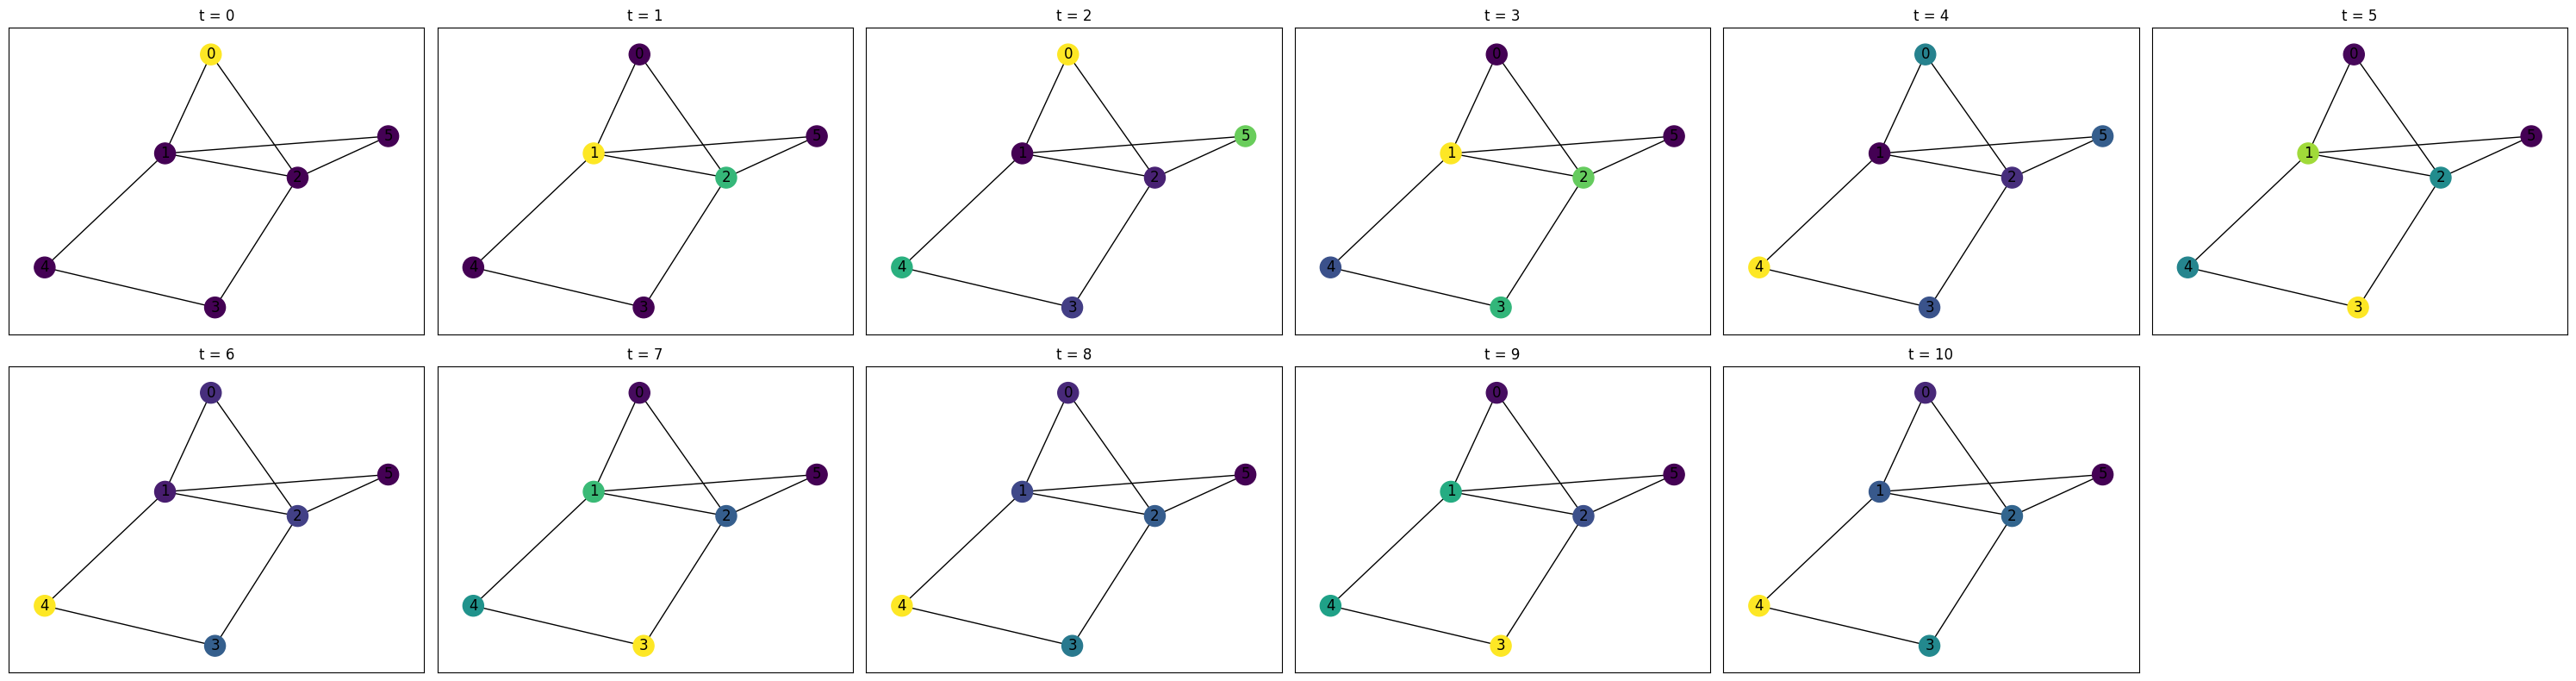

In [63]:
n = len(feature_hist)
rows = 2
cols = math.ceil(n / rows)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for t, (feat, ax) in enumerate(zip(feature_hist, axes)):
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feat,
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")
    
for ax in axes[len(feature_hist):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

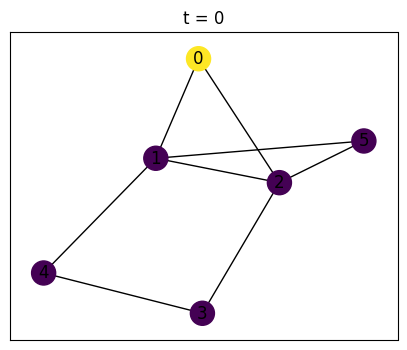

In [64]:
fig, ax = plt.subplots(figsize=(5,4))

def update(t):
    ax.clear()
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feature_hist[t],
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")

ani = FuncAnimation(fig, update, frames=len(feature_hist), interval=1000)

HTML(ani.to_jshtml())

## Laplacian Diffusion Matrix

In [84]:
features = np.array([G.nodes[i]['weights'] for i in G.nodes])
features

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [85]:
num_step = 10
feature_hist = [features.copy()]
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]])]

In [86]:
laplacian_mat = degree_mat - adjacency_mat
laplacian_mat

array([[ 2., -1., -1.,  0.,  0.,  0.],
       [-1.,  4., -1.,  0., -1., -1.],
       [-1., -1.,  6., -1.,  0., -3.],
       [ 0.,  0., -1.,  2., -1.,  0.],
       [ 0., -1.,  0., -1.,  2.,  0.],
       [ 0., -1., -3.,  0.,  0.,  4.]])

In [87]:
eigenvalues = np.linalg.eigvals(laplacian_mat)
eigenvalues

array([8.38066742e+00, 5.17704439e+00, 1.69504178e-15, 1.30838269e+00,
       2.37686470e+00, 2.75704080e+00])

In [88]:
spectral_radius = max(eigenvalues)
assert spectral_radius < 2 * np.max(degree_mat)
spectral_radius

np.float64(8.38066741644766)

In [89]:
for _ in range(num_step):
    features = features - spectral_radius * (laplacian_mat @ features)
    feature_hist.append(features)

In [90]:
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]]),
 array([[-15.76133483],
        [  8.38066742],
        [  8.38066742],
        [  0.        ],
        [  0.        ],
        [  0.        ]]),
 array([[ 388.8908484 ],
        [-334.41659689],
        [-474.88776958],
        [  70.23558635],
        [  70.23558635],
        [ 280.94234538]]),
 array([[-12911.94960927],
        [ 13098.51436605],
        [ 31512.97572662],
        [ -4498.26196062],
        [ -3321.01978071],
        [-23879.25874208]]),
 array([[  577383.62255602],
        [ -498066.13027976],
        [-2189592.91474963],
        [  307166.01952934],
        [  124419.55985784],
        [ 1678690.84308619]]),
 array([[-3.16247132e+07],
        [ 1.77983189e+07],
        [ 1.53356546e+08],
        [-2.21488775e+07],
        [-3.56088868e+06],
        [-1.13820384e+08]]),
 array([[ 1.93283969e+09],
        [-5.42388255e+08],
        [-1.07211938e+10],
        [ 1.60448346e+09],
        [ 

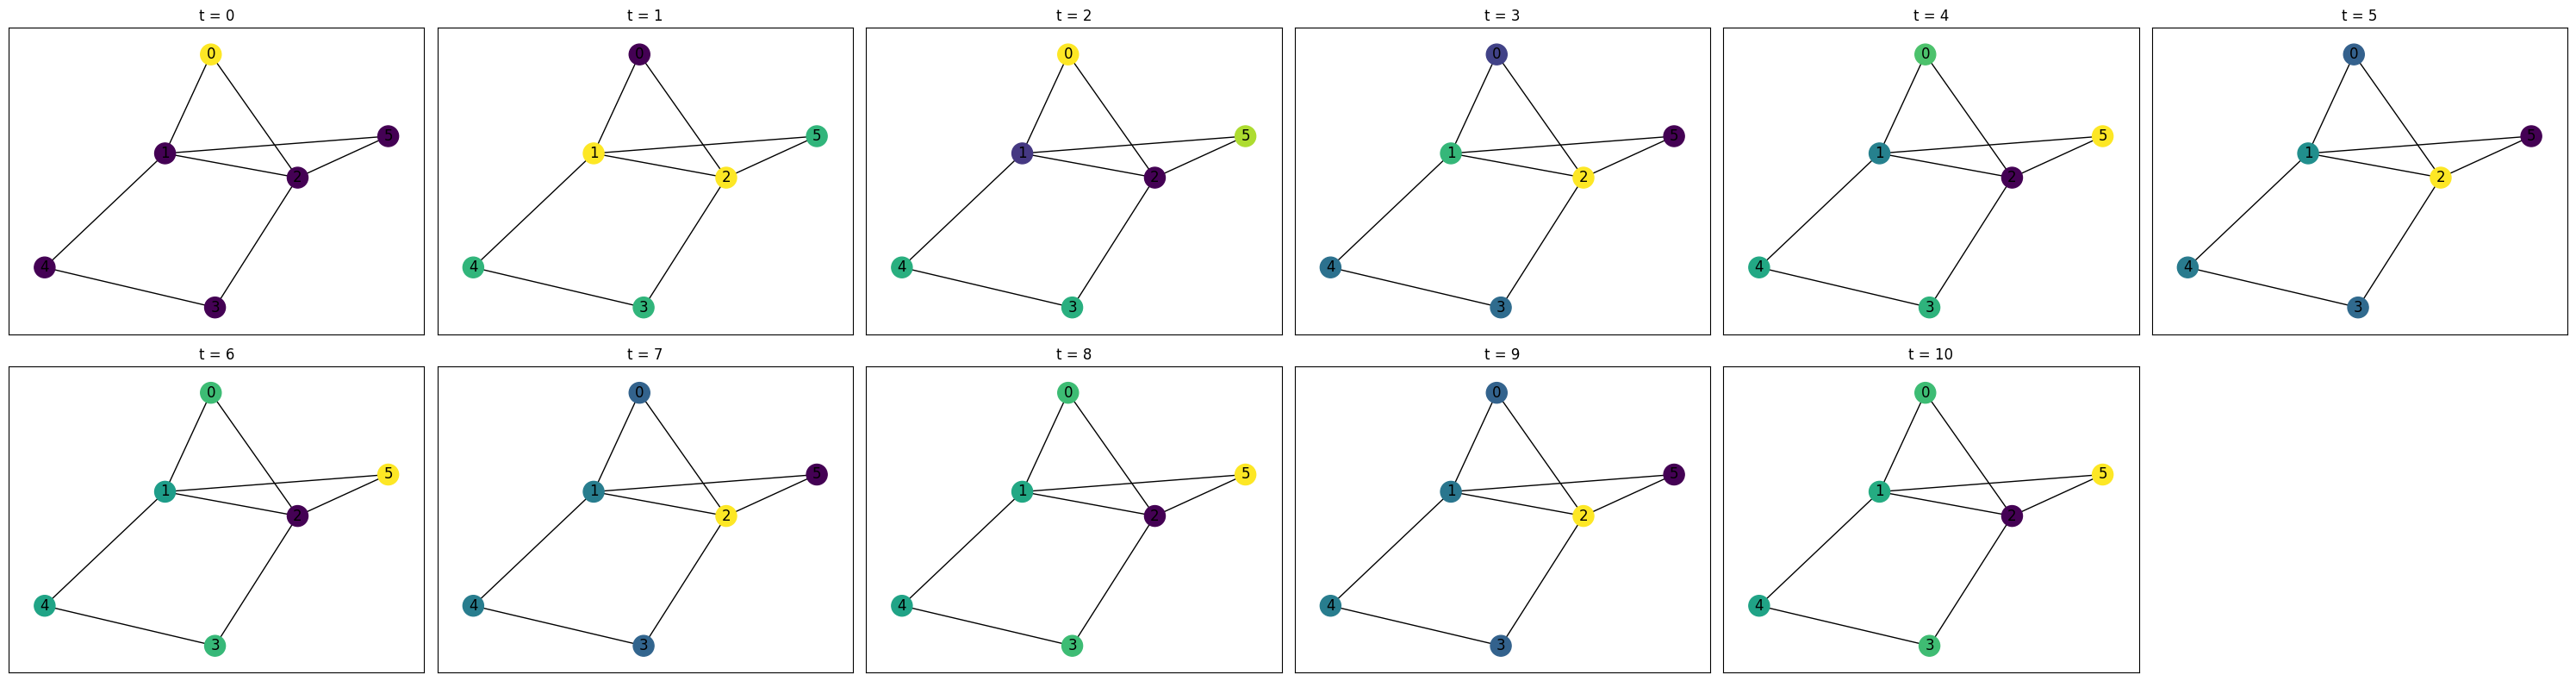

In [91]:
n = len(feature_hist)
rows = 2
cols = math.ceil(n / rows)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for t, (feat, ax) in enumerate(zip(feature_hist, axes)):
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feat,
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")
    
for ax in axes[len(feature_hist):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

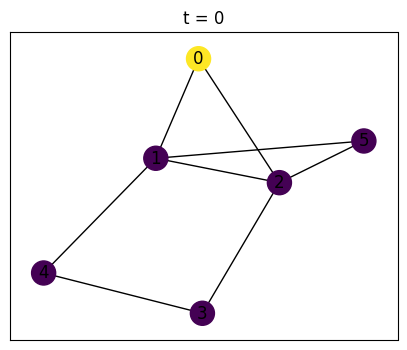

In [92]:
fig, ax = plt.subplots(figsize=(5,4))

def update(t):
    ax.clear()
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feature_hist[t],
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")

ani = FuncAnimation(fig, update, frames=len(feature_hist), interval=1000)

HTML(ani.to_jshtml())

## Asymmetric Laplacian Diffusion Matrix

In [95]:
I = np.identity(6)
I

array([[1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.]])

In [96]:
features = np.array([G.nodes[i]['weights'] for i in G.nodes])
features

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [97]:
num_step = 10
feature_hist = [features.copy()]
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]])]

In [98]:
for _ in range(num_step):
    features = features - spectral_radius * ((I - A_rw) @ features)
    feature_hist.append(features)

In [99]:
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]]),
 array([[-7.38066742],
        [ 2.09516685],
        [ 1.3967779 ],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ]]),
 array([[ 69.10666533],
        [-28.0009767 ],
        [-17.69182355],
        [  5.85296553],
        [  8.77944829],
        [ 13.16917244]]),
 array([[-701.52139418],
        [ 360.37459134],
        [ 251.35150324],
        [ -80.54461841],
        [-157.60574573],
        [-267.06596703]]),
 array([[ 7741.03257027],
        [-4492.74413468],
        [-3563.24663299],
        [  987.29904832],
        [ 2335.81656031],
        [ 4306.03999471]]),
 array([[-90891.27652795],
        [ 55828.4065685 ],
        [ 50259.05786228],
        [-12430.26752427],
        [-31928.86988518],
        [-63591.28639322]]),
 array([[1115380.16133348],
        [-697312.84436379],
        [-703751.46663744],
        [ 168553.2750526 ],
        [ 417509.05451681],
        [ 902219.298

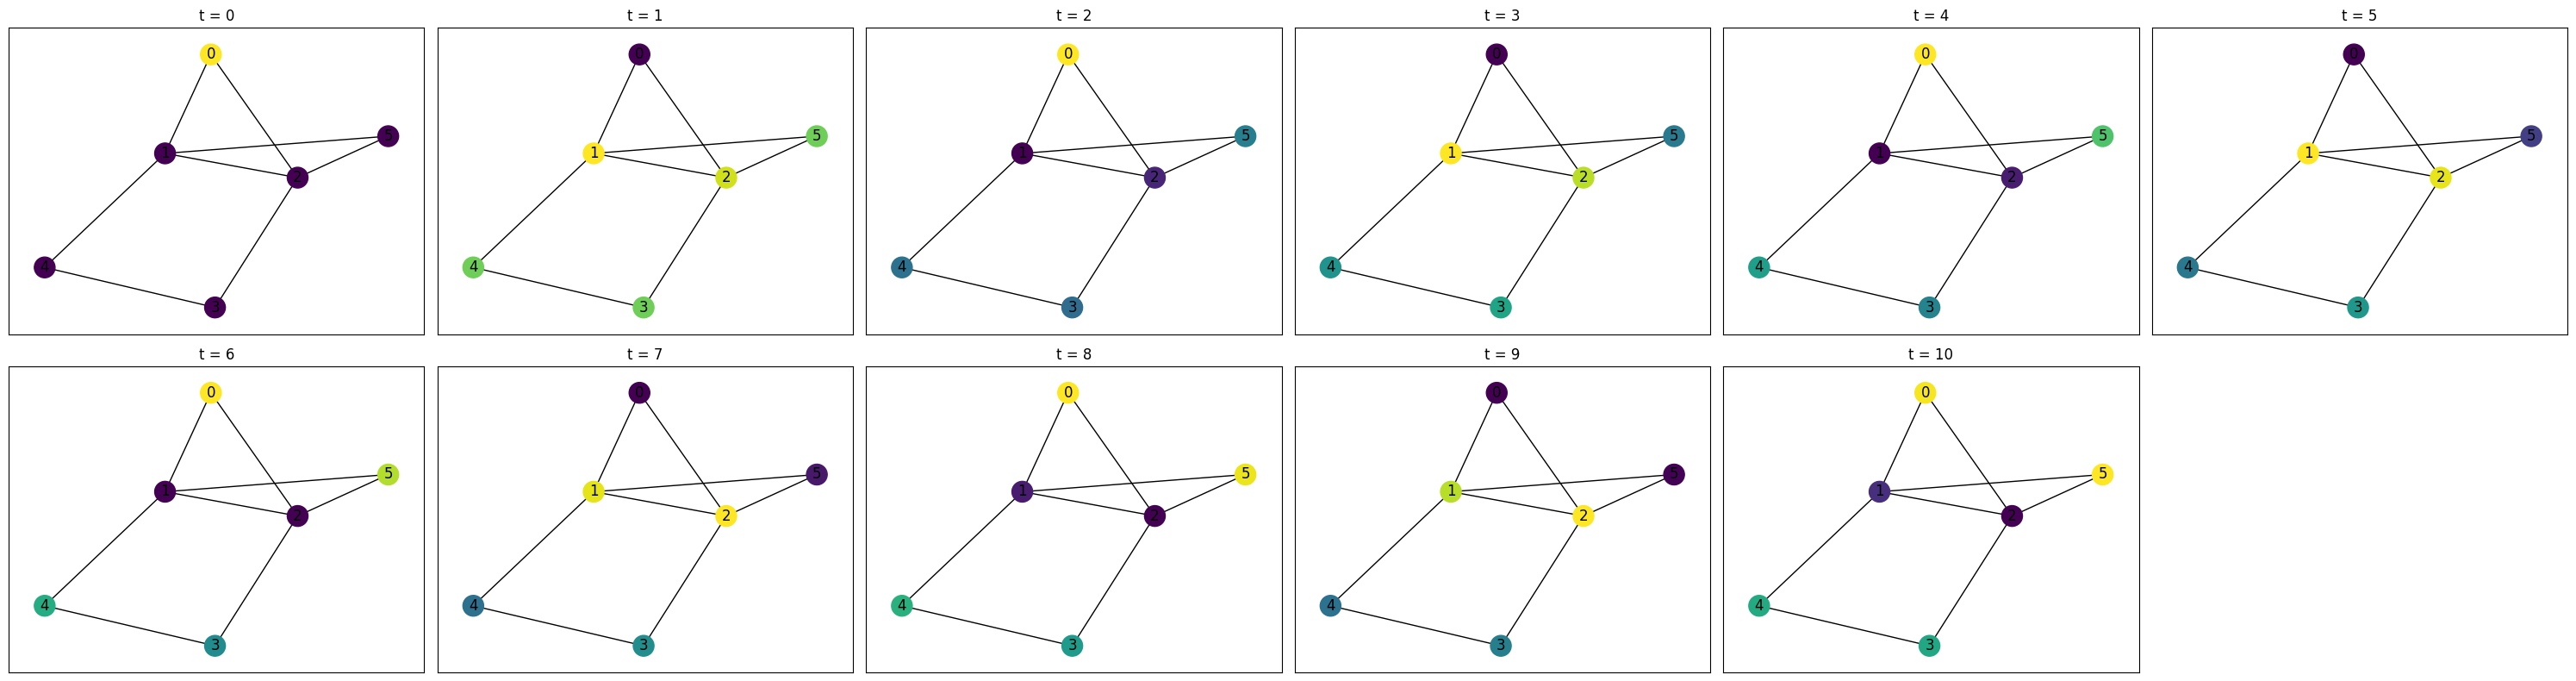

In [100]:
n = len(feature_hist)
rows = 2
cols = math.ceil(n / rows)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for t, (feat, ax) in enumerate(zip(feature_hist, axes)):
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feat,
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")
    
for ax in axes[len(feature_hist):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

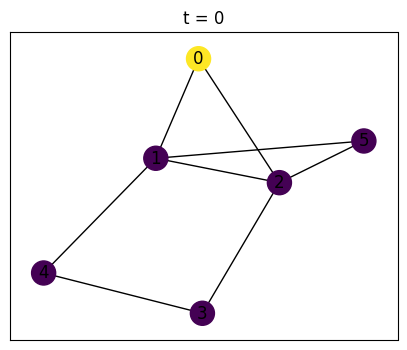

In [101]:
fig, ax = plt.subplots(figsize=(5,4))

def update(t):
    ax.clear()
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feature_hist[t],
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")

ani = FuncAnimation(fig, update, frames=len(feature_hist), interval=1000)

HTML(ani.to_jshtml())

## Symmetric Laplacian Diffusion Matrix

In [102]:
features = np.array([G.nodes[i]['weights'] for i in G.nodes])
features

array([[1],
       [0],
       [0],
       [0],
       [0],
       [0]])

In [103]:
num_step = 10
feature_hist = [features.copy()]
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]])]

In [104]:
for _ in range(num_step):
    features = features - spectral_radius * ((I - A_rw_twice) @ features)
    feature_hist.append(features)

In [105]:
feature_hist

[array([[1],
        [0],
        [0],
        [0],
        [0],
        [0]]),
 array([[-7.38066742],
        [ 1.04758343],
        [ 0.69838895],
        [ 0.        ],
        [ 0.        ],
        [ 0.        ]]),
 array([[ 56.05942968],
        [-15.21985617],
        [ -9.94334281],
        [  0.48774713],
        [  1.09743104],
        [  1.28033621]]),
 array([[-436.64439584],
        [ 169.40774565],
        [ 108.90699909],
        [  -8.24491896],
        [ -23.02193096],
        [ -27.83825142]]),
 array([[ 3476.25525659],
        [-1708.43277731],
        [-1084.51876357],
        [   88.67766291],
        [  330.11148157],
        [  408.28841592]]),
 array([[-28204.22568932],
        [ 16432.01097283],
        [ 10325.32295422],
        [  -720.27762487],
        [ -4040.37441957],
        [ -5044.42782279]]),
 array([[ 232591.00339022],
        [-154094.80041775],
        [ -95954.81976106],
        [   4061.96250513],
        [  45525.46039171],
        [  56654.832

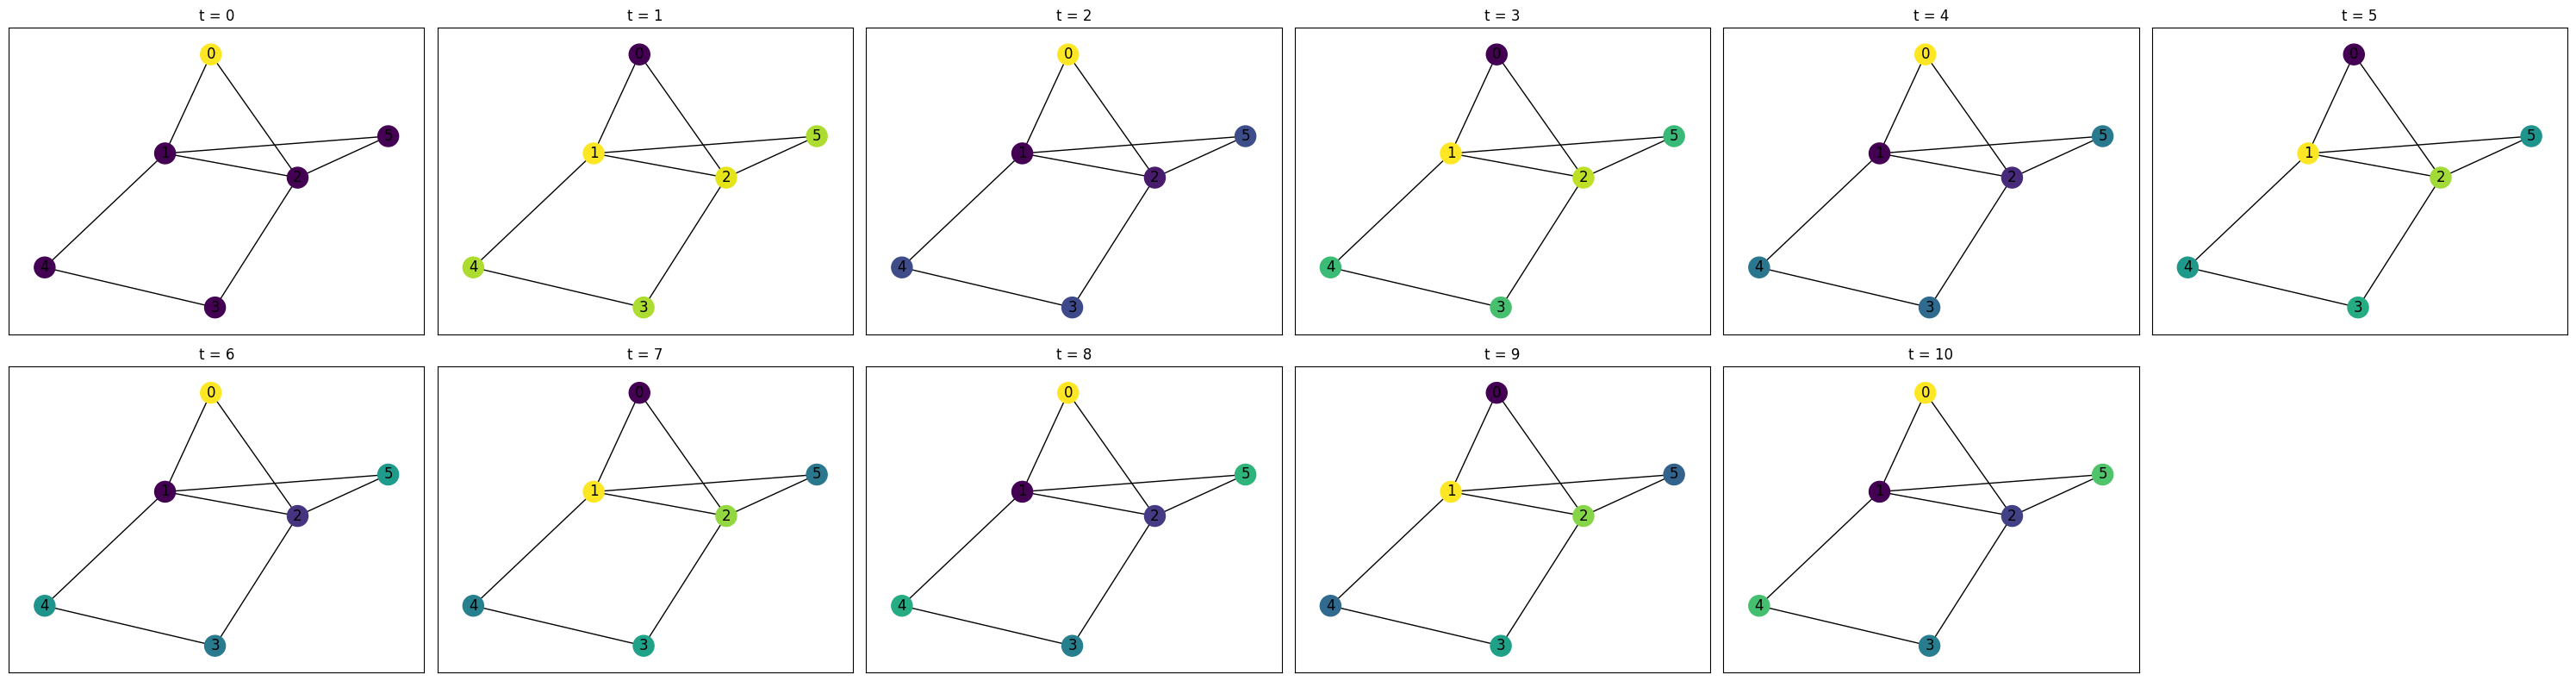

In [106]:
n = len(feature_hist)
rows = 2
cols = math.ceil(n / rows)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for t, (feat, ax) in enumerate(zip(feature_hist, axes)):
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feat,
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")
    
for ax in axes[len(feature_hist):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

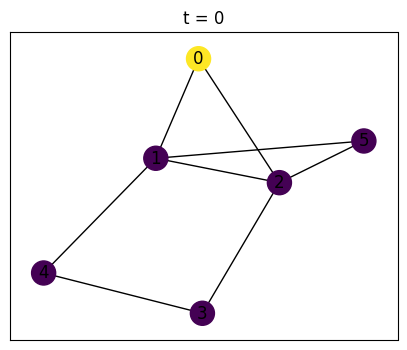

In [107]:
fig, ax = plt.subplots(figsize=(5,4))

def update(t):
    ax.clear()
    nx.draw_networkx_nodes(
        G, pos=pos,
        node_color=feature_hist[t],
        cmap=plt.cm.viridis,
        ax=ax
    )
    nx.draw_networkx_edges(G, pos=pos, ax=ax)
    nx.draw_networkx_labels(G, pos=pos, ax=ax)
    ax.set_title(f"t = {t}")

ani = FuncAnimation(fig, update, frames=len(feature_hist), interval=1000)

HTML(ani.to_jshtml())